In [3]:
VERSION, Sys.BINDIR, Base.DEPOT_PATH

(v"1.12.5", "/Users/mike/.julia/juliaup/julia-1.12.5+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/bin", ["/Users/mike/.julia", "/Users/mike/.julia/juliaup/julia-1.12.5+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/local/share/julia", "/Users/mike/.julia/juliaup/julia-1.12.5+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia"])

In [4]:
Base.active_project()

"/Users/mike/Desktop/Desktop - Mikayel’s MacBook Pro (2)/majority_colouring/Project.toml"

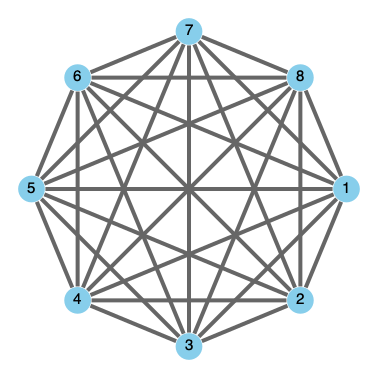

In [5]:
using Graphs, GraphPlot, Colors, Compose, Random, JuMP, HiGHS
import Cairo, Fontconfig

G = complete_graph(8)

gplot(G,
    layout=circular_layout,
    nodelabel=1:nv(G),
    nodefillc=fill(colorant"skyblue", nv(G)),
    edgestrokec=colorant"gray40"
)

In [6]:
function plot_digraph(G;
    layout=circular_layout,
    node_color=colorant"skyblue",
    edge_color=colorant"black",
    labels=true,
    save_path=nothing
)

    ctx = gplot(
        G,
        layout=layout,
        nodelabel=labels ? (1:nv(G)) : nothing,
        nodefillc=fill(node_color, nv(G)),
        edgestrokec=edge_color,
        arrowlengthfrac=0.08  # important for directed arrows
    )

    if save_path !== nothing
        draw(PNG(save_path, 800px, 800px), ctx)
    end

    return ctx
end


plot_digraph (generic function with 1 method)

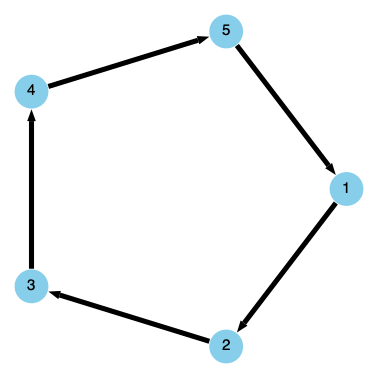

In [7]:
Random.seed!(42)

n = 5
G = DiGraph(n)

for i in 1:(n-1)
    add_edge!(G, i, i+1)
end
add_edge!(G, n, 1)

plot_digraph(G)

# Digraph Majority Coloring

This model implements a **Majority Coloring** constraint on a directed graph.  
For every vertex $v$, no more than half of its out-neighbors $N^+(v)$ may share the same color as $v$.

---

## Variables

* $x_{v,c} \in \{0,1\}$: Binary variable where $x_{v,c} = 1$ if vertex $v$ is assigned color $c$, and $0$ otherwise.

* $y_c \in \{0,1\}$: Binary variable where $y_c = 1$ if color $c$ is assigned to at least one vertex, and $0$ otherwise.

---

## Parameters

* $V$: Set of vertices.
* $N^+(v)$: Set of out-neighbors of vertex $v$.
* $d^+(v)$: Out-degree of vertex $v$, i.e., $|N^+(v)|$.
* $K$: Total number of available colors.

---

## Constraints

### A. Color Assignment (Uniqueness)

Each vertex must receive exactly one color:

$$
\forall v \in V:
\quad
\sum_{c=1}^{K} x_{v,c} = 1
$$

---

### B. Majority Constraint (Out-Neighbors)

If vertex $v$ has color $c$, then at most half of its out-neighbors may also have color $c$.

We use a Big-M formulation with $M = d^+(v)$:

$$
\forall v \in V,\; \forall c \in \{1,\dots,K\}:
$$

$$
\sum_{u \in N^+(v)} x_{u,c}
\le
\left\lfloor \frac{d^+(v)}{2} \right\rfloor
+
d^+(v)\bigl(1 - x_{v,c}\bigr)
$$

---

### C. Color Usage Linking

To ensure $y_c = 1$ whenever color $c$ is used:

$$
\forall v \in V,\; \forall c:
\quad
x_{v,c} \le y_c
$$

(Optional strengthening constraint:)

$$
\forall c:
\quad
y_c \le \sum_{v \in V} x_{v,c}
$$

---

## Objective

Minimize the number of used colors:

$$
\min \sum_{c=1}^{K} y_c
$$


In [8]:
using Graphs
using JuMP
using HiGHS

"""
Build + solve the Digraph Majority Coloring MILP.

Args:
- G::SimpleDiGraph : directed graph (Graphs.jl)
- K::Int           : max available colors

Kwargs:
- strengthen_y::Bool = true  : add y[c] ≤ ∑_v x[v,c] (tightens MILP)
- symmetry_break::Bool = true: add small symmetry breakers
- silent::Bool = true        : silence solver output

Returns:
- model::Model
- x_val::Matrix{Int}  (n×K) assignment matrix (0/1)
- y_val::Vector{Int}  (K) used colors (0/1)
- coloring::Vector{Int} (n) color label 1..K for each vertex
"""
function solve_majority_coloring_out(
    G::SimpleDiGraph,
    K::Int;
    strengthen_y::Bool = true,
    symmetry_break::Bool = true,
    silent::Bool = true
)
    n = nv(G)

    model = Model(HiGHS.Optimizer)
    if silent
        set_silent(model)
    end

    # Variables
    @variable(model, x[1:n, 1:K], Bin)
    @variable(model, y[1:K], Bin)

    # A) Color assignment uniqueness: ∑_c x[v,c] = 1
    @constraint(model, [v=1:n], sum(x[v,c] for c in 1:K) == 1)

    # B) Majority constraint on OUT-neighbors only
    for v in 1:n
        Nv = outneighbors(G, v)  # N⁺(v)
        dv = length(Nv)          # d⁺(v)
        if dv == 0
            continue
        end
        bound = fld(dv, 2)       # floor(d⁺(v)/2)

        for c in 1:K
            @constraint(model,
                sum(x[u,c] for u in Nv) <= bound + dv * (1 - x[v,c])
            )
        end
    end

    # C) Color usage linking: x[v,c] ≤ y[c]
    @constraint(model, [v=1:n, c=1:K], x[v,c] <= y[c])

    # Optional strengthening: y[c] ≤ ∑_v x[v,c]
    if strengthen_y
        @constraint(model, [c=1:K], y[c] <= sum(x[v,c] for v in 1:n))
    end

    # Optional symmetry breaking (helps a LOT when minimizing colors)
    if symmetry_break
        # force colors to be used in order: y1 ≥ y2 ≥ ... ≥ yK
        @constraint(model, [c=1:K-1], y[c] >= y[c+1])
        # fix first vertex to color 1
        @constraint(model, x[1,1] == 1)
    end

    # Objective: min ∑_c y[c]
    @objective(model, Min, sum(y[c] for c in 1:K))

    optimize!(model)

    # Extract solution (if feasible/optimal)
    status = termination_status(model)
    if status != MOI.OPTIMAL && status != MOI.FEASIBLE_POINT
        return model, nothing, nothing, nothing
    end

    x_val = round.(Int, value.(x))
    y_val = round.(Int, value.(y))

    # Convert x to a color label per vertex
    coloring = zeros(Int, n)
    for v in 1:n
        for c in 1:K
            if x_val[v,c] == 1
                coloring[v] = c
                break
            end
        end
    end

    return model, x_val, y_val, coloring
end

# --- Example ---
# G = erdos_renyi(SimpleDiGraph, 30, 0.15)
# model, x_val, y_val, coloring = solve_majority_coloring_out(G, 8)
# println("used colors = ", sum(y_val))
# println("coloring = ", coloring)


solve_majority_coloring_out

In [9]:
using Graphs
using JuMP
using HiGHS
using Random

println("Edges (u -> v):")
for e in edges(G)
    println(src(e), " -> ", dst(e))
end

# --- solve ---
K = n  # safe upper bound: at most n colors needed
model, x_val, y_val, coloring = solve_majority_coloring_out(G, K)

println("\nUsed colors = ", sum(y_val))
println("y = ", y_val)
println("coloring (vertex -> color) = ", coloring)

println("\nAssignment matrix x (rows=v, cols=c):")
display(x_val)

# --- optional: verify majority constraints ---
function check_majority_out(G, coloring)
    n = nv(G)
    ok = true
    for v in 1:n
        Nv = outneighbors(G, v)
        dv = length(Nv)
        if dv == 0
            continue
        end
        cv = coloring[v]
        same = count(u -> coloring[u] == cv, Nv)
        if same > fld(dv, 2)
            println("VIOLATION at v=$v: outdeg=$dv, same-color outneighbors=$same > floor(outdeg/2)=$(fld(dv,2))")
            ok = false
        end
    end
    return ok
end

println("\nMajority constraints satisfied? ", check_majority_out(G, coloring))


Edges (u -> v):
1 -> 2
2 -> 3
3 -> 4
4 -> 5
5 -> 1

Used colors = 3
y = [1, 1, 1, 0, 0]
coloring (vertex -> color) = [1, 3, 2, 1, 2]

Assignment matrix x (rows=v, cols=c):


5×5 Matrix{Int64}:
 1  0  0  0  0
 0  0  1  0  0
 0  1  0  0  0
 1  0  0  0  0
 0  1  0  0  0


Majority constraints satisfied? true


In [13]:
using Colors, GraphPlot, Compose, Graphs

function plot_advanced_digraph(G, coloring::Vector{Int}; 
                               total_k::Int=0, 
                               layout=circular_layout, 
                               save_path=nothing)
    
    # Color setup
    K = (total_k > 0) ? total_k : maximum(coloring)
    palette = distinguishable_colors(K, [colorant"white", colorant"black"], dropseed=true)
    node_fill_colors = [palette[c] for c in coloring]


    # select text color based on node color (white / black)
    function get_contrast_color(c)
        # Convert to LAB to check lightness (L is 0-100)
        return Lab(c).l < 50 ? colorant"white" : colorant"black"
    end
    node_label_colors = [get_contrast_color(c) for c in node_fill_colors]

    # labels
    node_labels = String[]
    for v in 1:nv(G)
        d_out = length(outneighbors(G, v))
        limit = floor(Int, d_out / 2)
        c_v = coloring[v]
        conflicts = count(u -> coloring[u] == c_v, outneighbors(G, v))
        
        # Use a compact format: "ID: C/L" to save vertical space
        push!(node_labels, "$v\n$conflicts/$limit")
    end


    ctx = gplot(
        G,
        layout=layout,
        nodelabel=node_labels,
        nodefillc=node_fill_colors,
        nodelabelc=node_label_colors,   # Apply contrast colors
        edgestrokec=colorant"gray60",   # Slightly lighter edges
        arrowlengthfrac=0.08,
        
        NODESIZE=0.10,                  # Larger nodes (was 0.05)
        NODELABELSIZE=3.0               # Smaller text (default is 4.0)
    )

    if save_path !== nothing
        draw(PNG(save_path, 1000px, 1000px), ctx)
    end

    return ctx
end

plot_advanced_digraph (generic function with 1 method)

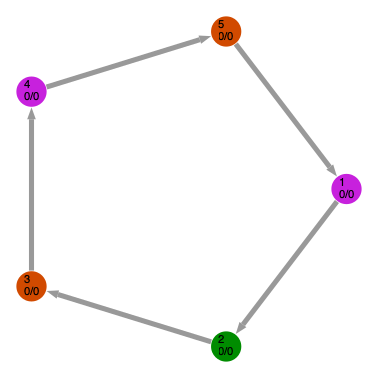

In [12]:
model, x_val, y_val, coloring = solve_majority_coloring_out(G, 4)

plot_advanced_digraph(G, coloring, total_k=3)